# Topic Modelling LDA Klasifikasi SVM

In [1]:
!pip install gensim

In [2]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.2 MB/s eta 0:00:00


In [11]:
import pandas as pd
import numpy as np
import re
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from IPython.display import display

# Define the text cleaning function
def pembersihan_teks(text):
    text = str(text)
    text = re.sub(r"[\[\]]", " ", text)    # hapus [ ]
    text = re.sub(r"[\'\"]", " ", text)    # hapus ' dan "
    text = re.sub(r",", " ", text)         # hapus koma
    text = re.sub(r"\s+", " ", text).strip()  # rapikan spasi
    return text.split() # Split the cleaned text into a list of words

In [4]:
berita_preprocessing = pd.read_csv("berita_preprocessed.csv")

In [5]:
# cek tipe data kolom isi berita hasil preprocessing
type(berita_preprocessing['Isi_Bersih'].iloc[0])

str

In [12]:
# Apply text cleaning to the 'body' column and store in 'Isi_Bersih'
berita_preprocessing['Isi_Bersih'] = berita_preprocessing['body'].apply(pembersihan_teks)

# Join the list of words back into strings for CountVectorizer
corpus = [' '.join(doc) for doc in berita_preprocessing['Isi_Bersih']]

print("Corpus created successfully.")
# Display the first element of the corpus to verify
print(corpus[0])

Corpus created successfully.
Satu jenazah korban reruntuhan bangunan Ponpes Al Khoziny Sidoarjo Jawa Timur belum teridentifikasi. Korban ditemukan dalam posisi bersujud di sebelah Haikal yang berhasil diselamatkan. SAR Mission Coordinator (SMC) Yudhi Bramantyo menjelaskan korban meninggal tanpa identitas itu berhasil dikeluarkan dari reruntuhan bangunan sekitar pukul 14.42 WIB Rabu (1/10/2025). Awalnya petugas hendak mengevakuasi Haikal. Namun ternyata posisinya berdekatan dengan korban yang meninggal dunia sehingga harus dievakuasi terlebih dahulu. Sujud itu kan yang tadi (sore) itu yang hitam yang sebelahan sama Haikal. Kita kan tadinya mau mengambil itu karena tidak bisa harus lewat situ Akhirnya kita tarik yang itu ujar Bramantyo seperti dilansirdetikJatim. Tak lama berselang pukul 15.22 WIB petugas baru berhasil mengevakuasi Haikal selaku korban ke-13. Ia dinyatakan selamat. Sesudah kita evakuasi dalam kondisi selamat atau merah. Selanjutnya kita rujuk ke Rumah Sakit Umum Daerah S

In [7]:
# Re-load the data to ensure the DataFrame is fresh
berita_preprocessing = pd.read_csv("berita_preprocessed.csv")
print("Data reloaded.")

Data reloaded.


In [10]:
import pandas as pd
import numpy as np
import re
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from IPython.display import display

In [15]:
# Load the data from the file that was successfully loaded earlier
berita_preprocessing = pd.read_csv("berita_preprocessed.csv")
print("Data loaded successfully from 'berita_preprocessed.csv'.")

Data loaded successfully from 'berita_preprocessed.csv'.


In [16]:
# Define the text cleaning function (as previously corrected)
def pembersihan_teks(text):
    text = str(text)
    text = re.sub(r"[\[\]]", " ", text)    # hapus [ ]
    text = re.sub(r"[\'\"]", " ", text)    # hapus ' dan "
    text = re.sub(r",", " ", text)         # hapus koma
    text = re.sub(r"\s+", " ", text).strip()  # rapikan spasi
    return text.split() # Split the cleaned text into a list of words

In [17]:
# Apply text cleaning to the 'body' column and store in 'Isi_Bersih'
berita_preprocessing['Isi_Bersih'] = berita_preprocessing['body'].apply(pembersihan_teks)
print("'Isi_Bersih' column created/re-processed.")
# Verify the data type again
print("Data type of 'Isi_Bersih' column after re-processing:", type(berita_preprocessing['Isi_Bersih'].iloc[0]))

'Isi_Bersih' column created/re-processed.
Data type of 'Isi_Bersih' column after re-processing: <class 'list'>


In [18]:
# Now, try creating the corpus again from the re-processed 'Isi_Bersih' column
corpus = [' '.join(doc) for doc in berita_preprocessing['Isi_Bersih']]

print("Corpus created successfully.")
# Display the first element of the corpus to verify
print(corpus[0])

Corpus created successfully.
Satu jenazah korban reruntuhan bangunan Ponpes Al Khoziny Sidoarjo Jawa Timur belum teridentifikasi. Korban ditemukan dalam posisi bersujud di sebelah Haikal yang berhasil diselamatkan. SAR Mission Coordinator (SMC) Yudhi Bramantyo menjelaskan korban meninggal tanpa identitas itu berhasil dikeluarkan dari reruntuhan bangunan sekitar pukul 14.42 WIB Rabu (1/10/2025). Awalnya petugas hendak mengevakuasi Haikal. Namun ternyata posisinya berdekatan dengan korban yang meninggal dunia sehingga harus dievakuasi terlebih dahulu. Sujud itu kan yang tadi (sore) itu yang hitam yang sebelahan sama Haikal. Kita kan tadinya mau mengambil itu karena tidak bisa harus lewat situ Akhirnya kita tarik yang itu ujar Bramantyo seperti dilansirdetikJatim. Tak lama berselang pukul 15.22 WIB petugas baru berhasil mengevakuasi Haikal selaku korban ke-13. Ia dinyatakan selamat. Sesudah kita evakuasi dalam kondisi selamat atau merah. Selanjutnya kita rujuk ke Rumah Sakit Umum Daerah S

In [19]:
# Removed redundant function call

In [20]:
# cek tipe data kolom isi berita hasil preprocessing
type(berita_preprocessing['Isi_Bersih'].iloc[0])

list

In [21]:
# menampilkan data
display(berita_preprocessing.head())

,source,kategori,url,title,published,body,Isi_Bersih
0,detik,nasional,https://news.detik.com/berita/d-8141021/1-jena...,1 Jenazah Santri Korban Runtuhan Ponpes Sidoar...,"Kamis, 02 Okt 2025 11:01 WIB",Satu jenazah korban reruntuhan bangunan Ponpes...,"[Satu, jenazah, korban, reruntuhan, bangunan, ..."
1,detik,nasional,https://news.detik.com/berita/d-8141018/siswi-...,Siswi di Bandung Barat Meninggal Diduga Keracu...,"Kamis, 02 Okt 2025 11:00 WIB","Seorang siswi SMK Negeri 1 Cihampelas, Kabupat...","[Seorang, siswi, SMK, Negeri, 1, Cihampelas, K..."
2,detik,nasional,https://news.detik.com/berita/d-8140924/jawab-...,"Jawab Kebingungan Umat, Ini Klasifikasi Produk...","Kamis, 02 Okt 2025 11:00 WIB",Seiring dengan maraknya seruan boikot terhadap...,"[Seiring, dengan, maraknya, seruan, boikot, te..."
3,detik,nasional,https://news.detik.com/berita/d-8141016/bejat-...,Bejat! Duo Kakek Kembar di Bekasi Lecehkan Wan...,"Kamis, 02 Okt 2025 10:59 WIB",Seorang wanita berinisial N yang merupakanpeny...,"[Seorang, wanita, berinisial, N, yang, merupak..."
4,detik,nasional,https://news.detik.com/berita/d-8140970/menkum...,Menkum Resmi Teken SK Kepengurusan PPP Ketum M...,"Kamis, 02 Okt 2025 10:45 WIB",Menteri Hukum Supratman Andi Agtas resmi menan...,"[Menteri, Hukum, Supratman, Andi, Agtas, resmi..."


In [22]:
# Removed redundant function definition

In [23]:
# Gunakan kolom yang benar dari dataset
berita_preprocessing['isi_berita_preprocessing_bersih'] = berita_preprocessing['Isi_Bersih'].apply(pembersihan_teks)


In [24]:
display(berita_preprocessing[["body", "Isi_Bersih"]].head(10))

,body,Isi_Bersih
0,Satu jenazah korban reruntuhan bangunan Ponpes...,"[Satu, jenazah, korban, reruntuhan, bangunan, ..."
1,"Seorang siswi SMK Negeri 1 Cihampelas, Kabupat...","[Seorang, siswi, SMK, Negeri, 1, Cihampelas, K..."
2,Seiring dengan maraknya seruan boikot terhadap...,"[Seiring, dengan, maraknya, seruan, boikot, te..."
3,Seorang wanita berinisial N yang merupakanpeny...,"[Seorang, wanita, berinisial, N, yang, merupak..."
4,Menteri Hukum Supratman Andi Agtas resmi menan...,"[Menteri, Hukum, Supratman, Andi, Agtas, resmi..."
5,"Kuasa Hukum Staf Ahli KemensosEdi Suharto, Fai...","[Kuasa, Hukum, Staf, Ahli, KemensosEdi, Suhart..."
6,"Eksdosen UIN Malang Maulana Malik Ibrahim, Ima...","[Eksdosen, UIN, Malang, Maulana, Malik, Ibrahi..."
7,Federasi Panjat Tebing Indonesia (FPTI) mengec...,"[Federasi, Panjat, Tebing, Indonesia, (FPTI), ..."
8,Polisi mengungkap kecepatan mobil Honda HR-V s...,"[Polisi, mengungkap, kecepatan, mobil, Honda, ..."
9,KPK akan melakukan monitoring terhadap adanya ...,"[KPK, akan, melakukan, monitoring, terhadap, a..."


In [25]:
# cek tipe data kolom isi berita hasil preprocessing yang sudah dibersihkan
type(berita_preprocessing['isi_berita_preprocessing_bersih'].iloc[0])

list

In [26]:
# Join the list of words in 'Isi_Bersih' into strings and then create the corpus list
corpus = [' '.join(doc) for doc in berita_preprocessing['Isi_Bersih']]

In [27]:
print(corpus)

['Satu jenazah korban reruntuhan bangunan Ponpes Al Khoziny Sidoarjo Jawa Timur belum teridentifikasi. Korban ditemukan dalam posisi bersujud di sebelah Haikal yang berhasil diselamatkan. SAR Mission Coordinator (SMC) Yudhi Bramantyo menjelaskan korban meninggal tanpa identitas itu berhasil dikeluarkan dari reruntuhan bangunan sekitar pukul 14.42 WIB Rabu (1/10/2025). Awalnya petugas hendak mengevakuasi Haikal. Namun ternyata posisinya berdekatan dengan korban yang meninggal dunia sehingga harus dievakuasi terlebih dahulu. Sujud itu kan yang tadi (sore) itu yang hitam yang sebelahan sama Haikal. Kita kan tadinya mau mengambil itu karena tidak bisa harus lewat situ Akhirnya kita tarik yang itu ujar Bramantyo seperti dilansirdetikJatim. Tak lama berselang pukul 15.22 WIB petugas baru berhasil mengevakuasi Haikal selaku korban ke-13. Ia dinyatakan selamat. Sesudah kita evakuasi dalam kondisi selamat atau merah. Selanjutnya kita rujuk ke Rumah Sakit Umum Daerah Sidoarjo tutur Bramantyo. Ba

In [28]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

In [29]:
# Menampilkan jumlah dokumen dan fitur
print("Jumlah Dokumen :", X.shape[0])
print("Jumlah Fitur (Kosakata) :", X.shape[1])

Jumlah Dokumen : 400
Jumlah Fitur (Kosakata) : 7824


In [30]:
jumlah_topik = 400

In [31]:
lda_model = LatentDirichletAllocation(
    n_components=jumlah_topik,
    max_iter=20,           # jumlah iterasi agar konvergen
    learning_method='batch',
    random_state=42
)

In [32]:
lda_model

LatentDirichletAllocation(max_iter=20, n_components=400, random_state=42)

In [33]:
lda_output = lda_model.fit_transform(X)

In [34]:
lda_output

array([[1.73611111e-05, 1.73611111e-05, 1.73611111e-05, ...,
        1.73611111e-05, 1.73611111e-05, 1.73611111e-05],
       [8.44594595e-06, 8.44594595e-06, 8.44594595e-06, ...,
        8.44594595e-06, 8.44594595e-06, 8.44594595e-06],
       [5.93824228e-06, 5.93847539e-06, 5.93824228e-06, ...,
        5.93824228e-06, 5.93824228e-06, 5.93824228e-06],
       ...,
       [1.25628141e-05, 1.25628141e-05, 1.25628141e-05, ...,
        1.25628141e-05, 1.25628141e-05, 1.25628141e-05],
       [7.26744186e-06, 7.26744186e-06, 7.26744186e-06, ...,
        7.26744186e-06, 7.26744186e-06, 7.26744186e-06],
       [9.88142292e-06, 9.88142292e-06, 9.88142292e-06, ...,
        9.88142292e-06, 9.88142292e-06, 9.88142292e-06]])

In [35]:
# Menghitung metrik kinerja model
log_likelihood = lda_model.score(X)
perplexity = lda_model.perplexity(X)

print("Metrik Kinerja Model LDA:")
print(f"Log-Likelihood : {log_likelihood:.2f}")
print(f"Perplexity     : {perplexity:.2f}")

Metrik Kinerja Model LDA:
Log-Likelihood : -869273.90
Perplexity     : 813.47


In [36]:
kolom_topik = [f'T{i+1}' for i in range(jumlah_topik)]
df_topik_dokumen = pd.DataFrame(lda_output, columns=kolom_topik)

In [37]:
display(df_topik_dokumen)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T391,T392,T393,T394,T395,T396,T397,T398,T399,T400
0,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,...,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017
1,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008
2,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
3,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
4,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
396,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004
397,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013
398,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,...,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007


In [38]:
# kategori_berita dipindah ke kolom terakhir
df_hasil_topik = pd.concat([
    berita_preprocessing[['url', 'title', 'published', 'body', 'Isi_Bersih', 'isi_berita_preprocessing_bersih', 'kategori']],
    df_topik_dokumen
], axis=1)

In [39]:
display(df_hasil_topik)

,url,title,published,body,Isi_Bersih,isi_berita_preprocessing_bersih,kategori,T1,T2,T3,...,T391,T392,T393,T394,T395,T396,T397,T398,T399,T400
0,https://news.detik.com/berita/d-8141021/1-jena...,1 Jenazah Santri Korban Runtuhan Ponpes Sidoar...,"Kamis, 02 Okt 2025 11:01 WIB",Satu jenazah korban reruntuhan bangunan Ponpes...,"[Satu, jenazah, korban, reruntuhan, bangunan, ...","[Satu, jenazah, korban, reruntuhan, bangunan, ...",nasional,0.000017,0.000017,0.000017,...,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017
1,https://news.detik.com/berita/d-8141018/siswi-...,Siswi di Bandung Barat Meninggal Diduga Keracu...,"Kamis, 02 Okt 2025 11:00 WIB","Seorang siswi SMK Negeri 1 Cihampelas, Kabupat...","[Seorang, siswi, SMK, Negeri, 1, Cihampelas, K...","[Seorang, siswi, SMK, Negeri, 1, Cihampelas, K...",nasional,0.000008,0.000008,0.000008,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008
2,https://news.detik.com/berita/d-8140924/jawab-...,"Jawab Kebingungan Umat, Ini Klasifikasi Produk...","Kamis, 02 Okt 2025 11:00 WIB",Seiring dengan maraknya seruan boikot terhadap...,"[Seiring, dengan, maraknya, seruan, boikot, te...","[Seiring, dengan, maraknya, seruan, boikot, te...",nasional,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
3,https://news.detik.com/berita/d-8141016/bejat-...,Bejat! Duo Kakek Kembar di Bekasi Lecehkan Wan...,"Kamis, 02 Okt 2025 10:59 WIB",Seorang wanita berinisial N yang merupakanpeny...,"[Seorang, wanita, berinisial, N, yang, merupak...","[Seorang, wanita, berinisial, N, yang, merupak...",nasional,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
4,https://news.detik.com/berita/d-8140970/menkum...,Menkum Resmi Teken SK Kepengurusan PPP Ketum M...,"Kamis, 02 Okt 2025 10:45 WIB",Menteri Hukum Supratman Andi Agtas resmi menan...,"[Menteri, Hukum, Supratman, Andi, Agtas, resmi...","[Menteri, Hukum, Supratman, Andi, Agtas, resmi...",nasional,0.000009,0.000009,0.000009,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,https://news.detik.com/berita/d-8139352/hari-k...,"Hari Kesaktian Pancasila, Puan Ingatkan Bahaya...","Rabu, 01 Okt 2025 13:04 WIB",Ketua DPR RI Puan Maharani memimpin pembacaan ...,"[Ketua, DPR, RI, Puan, Maharani, memimpin, pem...","[Ketua, DPR, RI, Puan, Maharani, memimpin, pem...",internasional,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
396,https://news.detik.com/berita/d-8139351/pemoho...,Pemohon Minta MK Hapus Pensiun DPR: Jabat 5 Ta...,"Rabu, 01 Okt 2025 13:04 WIB",Warga bernama Lita Linggayani Gading dan Syams...,"[Warga, bernama, Lita, Linggayani, Gading, dan...","[Warga, bernama, Lita, Linggayani, Gading, dan...",internasional,0.000004,0.000004,0.000004,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004
397,https://news.detik.com/berita/d-8139341/awal-m...,Awal Mula Temuan Pria Tewas dalam Mobil yang T...,"Rabu, 01 Okt 2025 13:02 WIB",Polisi mengungkap awal mulapenemuan pria tak b...,"[Polisi, mengungkap, awal, mulapenemuan, pria,...","[Polisi, mengungkap, awal, mulapenemuan, pria,...",internasional,0.000013,0.000013,0.000013,...,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013
398,https://news.detik.com/berita/d-8139339/menkes...,Menkes Minta Penerbitan Sertifikat Higiene unt...,"Rabu, 01 Okt 2025 13:02 WIB",Menteri Kesehatan (Menkes)Budi Gunadi Sadikinm...,"[Menteri, Kesehatan, (Menkes)Budi, Gunadi, Sad...","[Menteri, Kesehatan, (Menkes)Budi, Gunadi, Sad...",internasional,0.000007,0.000007,0.000007,...,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.0000

In [40]:
df_hasil_topik.to_csv("BeritaOnline_TopicModeling.csv", index=False)

In [41]:
def tampilkan_topik(model, feature_names, n_kata_teratas=10):
    topik_list = []
    for idx, topik in enumerate(model.components_):
        kata_teratas = [feature_names[i] for i in topik.argsort()[:-n_kata_teratas - 1:-1]]
        bobot_kata = topik[topik.argsort()[:-n_kata_teratas - 1:-1]]
        topik_list.append(pd.DataFrame({'Kata': kata_teratas, 'Bobot': bobot_kata}))
        print(f"\n🔹 Topik {idx+1}:")
        print(", ".join(kata_teratas))
    return topik_list

In [42]:
fitur_kata = vectorizer.get_feature_names_out()
topik_dominan = tampilkan_topik(lda_model, fitur_kata, n_kata_teratas=10)


🔹 Topik 1:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 2:
halal, produk, yang, juga, di, sertifikat, sertifikasi, lebih, dan, dalam

🔹 Topik 3:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 4:
kanker, yang, dalam, hasbullah, pengobatan, ketua, dan, pasien, ri, kesehatan

🔹 Topik 5:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 6:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 7:
yang, di, narkotika, bogor, narkoba, dan, ada, polresta, peredaran, 2025

🔹 Topik 8:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 9:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 10:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 11:
yang, itu, di, dan, mobil, saudara, rk, hilang, ke, kami

🔹 Topik 12:
zubaedi, hpk, hr, ht, hub, hubungan, hubungannya, huda, huis, hujan

🔹 Topik 13:
zubaedi, hpk, 

In [43]:
daftar_topik = []
for i, df in enumerate(topik_dominan, start=1):
    df_temp = df.copy()
    df_temp['Topik'] = f'T{i}'
    daftar_topik.append(df_temp)

In [44]:
df_kata_topik = pd.concat(daftar_topik)

In [45]:
display(df_kata_topik)

,Kata,Bobot,Topik
0,zubaedi,0.0025,T1
1,hpk,0.0025,T1
2,hr,0.0025,T1
3,ht,0.0025,T1
4,hub,0.0025,T1
...,...,...,...
5,hubungan,0.0025,T400
6,hubungannya,0.0025,T400
7,huda,0.0025,T400
8,huis,0.0025,T400


In [46]:
df_kata_topik.to_csv("BeritaOnline_TopicModelling_KataTopik.csv", index=False)

/tmp/ipython-input-1532239002.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


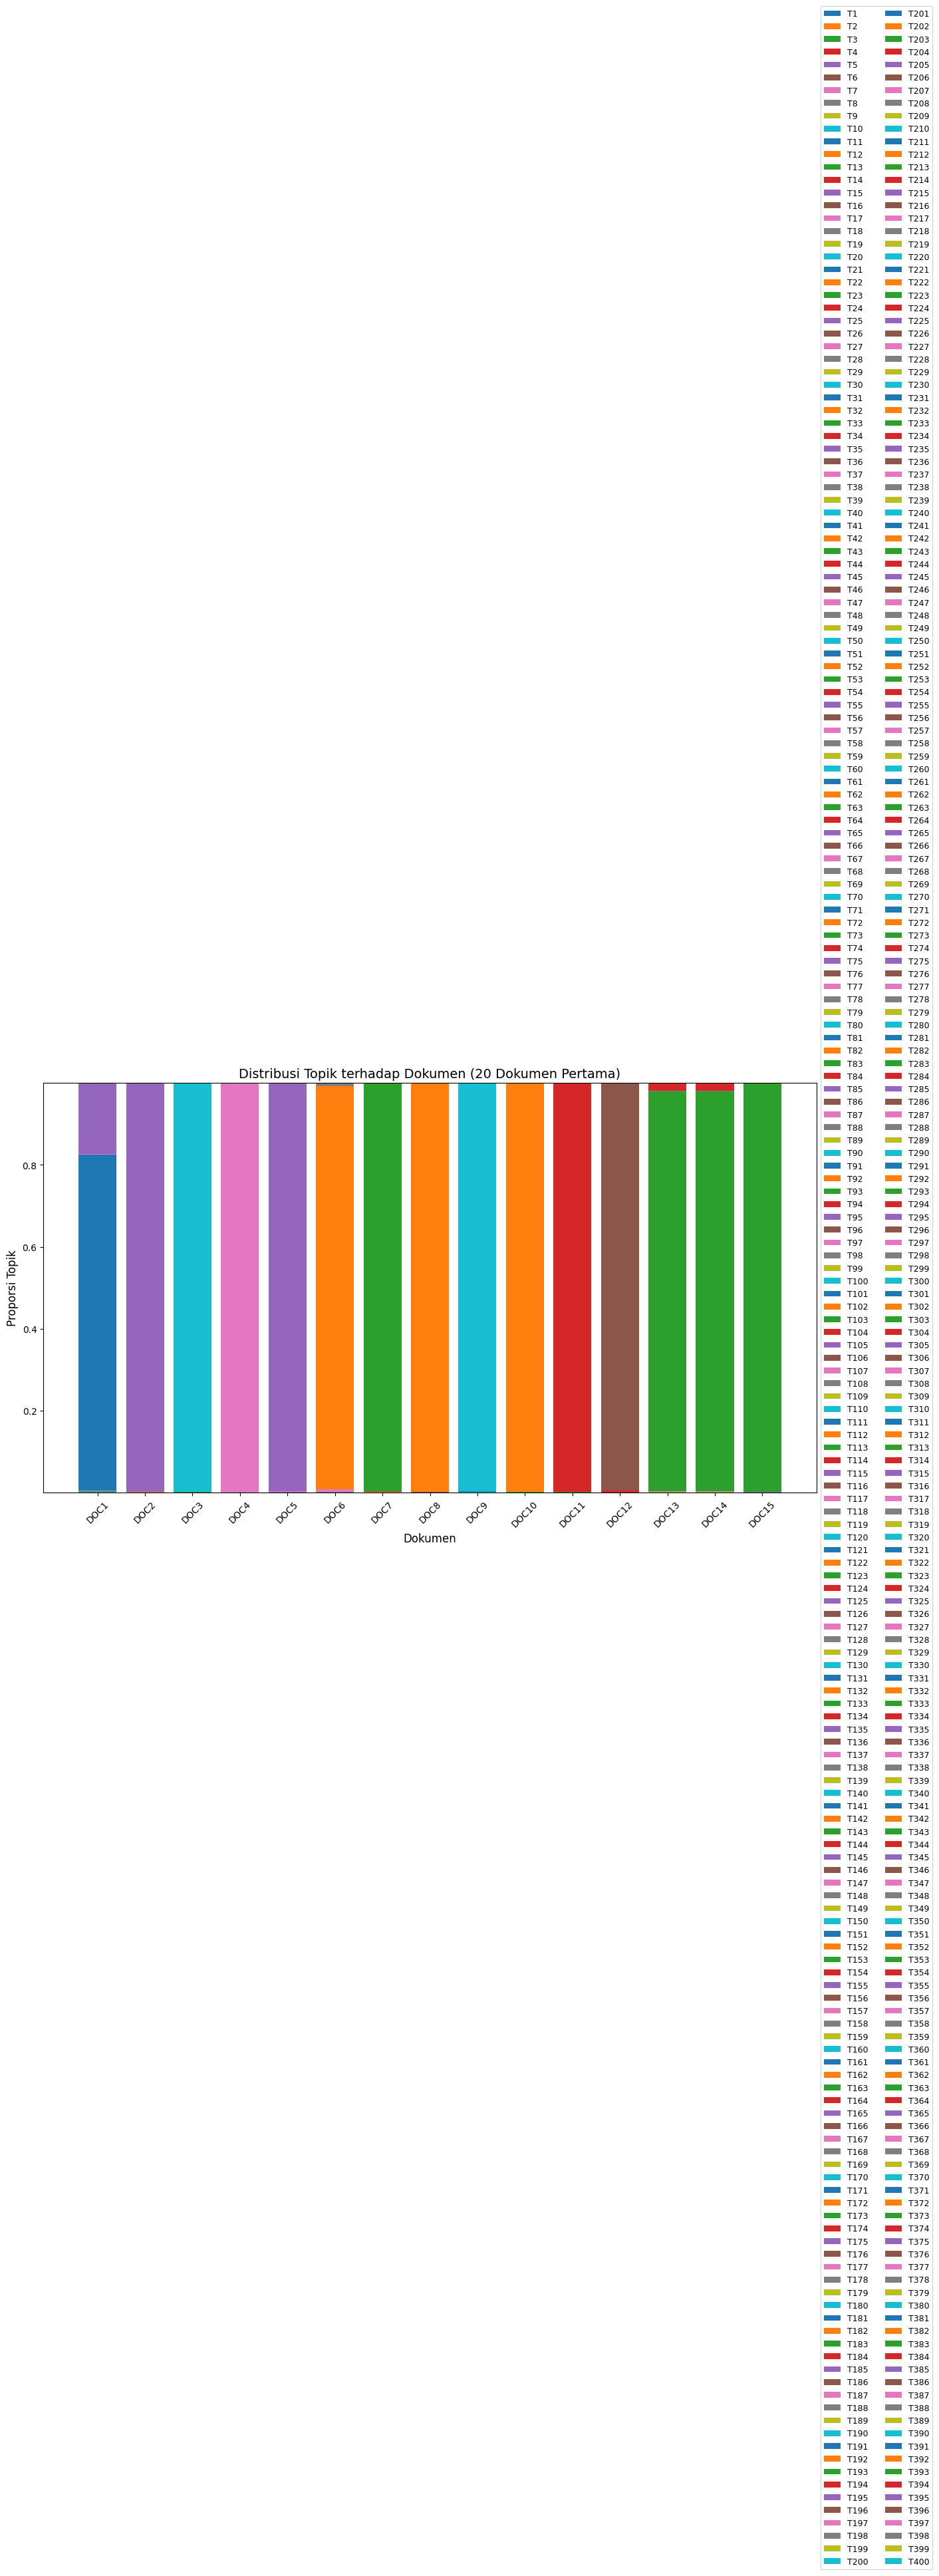

In [47]:
# ============================================================
# 1️⃣4️⃣ MEMVISUALISASIKAN DISTRIBUSI TOPIK PER DOKUMEN
# ============================================================
import matplotlib.pyplot as plt

# Ambil hanya kolom topik dari DataFrame hasil topik modelling
df_topik_only = df_hasil_topik[[f'T{i+1}' for i in range(jumlah_topik)]]

# Batasi visualisasi hanya untuk beberapa dokumen pertama (misal 15 dokumen)
# karena jika 1000 dokumen divisualisasi semua akan terlalu padat
jumlah_dokumen_visualisasi = 15
df_topik_visual = df_topik_only.head(jumlah_dokumen_visualisasi)

# Membuat label sumbu X (misal: DOC1, DOC2, ..., DOC20)
x_axis = [f'DOC{i+1}' for i in range(jumlah_dokumen_visualisasi)]

# Buat stacked bar plot
fig, ax = plt.subplots(figsize=(15, 8))

# Inisialisasi posisi bottom (awal tumpukan)
bottom = np.zeros(len(x_axis))

# Untuk setiap topik, tambahkan batangnya secara bertumpuk
for col in df_topik_visual.columns:
    ax.bar(x_axis, df_topik_visual[col], bottom=bottom, label=col)
    bottom += np.array(df_topik_visual[col])

# Judul dan label sumbu
ax.set_title("Distribusi Topik terhadap Dokumen (20 Dokumen Pertama)", fontsize=14)
ax.set_xlabel("Dokumen", fontsize=12)
ax.set_ylabel("Proporsi Topik", fontsize=12)

# Pindahkan legend ke luar grafik agar tidak menutupi batang
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# 1️⃣5️⃣ VISUALISASI TOPIC MODELLING (INTERAKTIF DENGAN pyLDAvis)
# ============================================================

import pyLDAvis
import warnings
warnings.filterwarnings("ignore")

# Aktifkan tampilan interaktif di notebook
pyLDAvis.enable_notebook()

# 🔹 Gunakan modul utama pyLDAvis langsung
lda_visualization = pyLDAvis.prepare(
    topic_term_dists=lda_model.components_,   # distribusi kata terhadap topik
    doc_topic_dists=lda_output,               # distribusi topik terhadap dokumen
    doc_lengths=X.sum(axis=1).A1,             # panjang setiap dokumen
    vocab=vectorizer.get_feature_names_out(), # daftar kata
    term_frequency=X.sum(axis=0).A1           # frekuensi setiap kata
)

# Tampilkan visualisasi interaktif
lda_visualization

TypeError: Object of type complex128 is not JSON serializable

PreparedData(topic_coordinates=                        x                   y  topics  cluster      Freq
topic                                                                   
231    1.697484+0.000000j -0.221028+0.000000j       1        1  3.221611
256    1.610257+0.000000j -0.121599+0.000000j       2        1  2.829376
159    1.459452+0.000000j -0.180270+0.000000j       3        1  2.116975
140    1.452128+0.000000j  0.119469+0.000000j       4        1  1.778509
288    1.351212+0.000000j  0.230220+0.000000j       5        1  1.557646
...                   ...                 ...     ...      ...       ...
156   -0.516191+0.000000j -0.000492+0.000000j     396        1  0.000768
155   -0.516191+0.000000j -0.000492+0.000000j     397        1  0.000768
153   -0.516191+0.000000j -0.000492+0.000000j     398        1  0.000768
150   -0.516191+0.000000j -0.000492+0.000000j     399        1  0.000768
399   -0.516191+0.000000j -0.000492+0.000000j     400        1  0.000768

[400 rows x 5 colum

In [63]:
from gensim import corpora
from gensim.models import CoherenceModel
import numpy as np
import pandas as pd
from IPython.display import display

In [64]:
# 1️⃣ Ambil fitur dari CountVectorizer yang sudah digunakan sebelumnya
vocab = vectorizer.get_feature_names_out()

# 2️⃣ Buat dictionary dan corpus dalam format gensim
# Menggunakan corpus hasil preprocessing final kamu (sudah berupa teks bersih)
tokenized_text = [doc.split() for doc in corpus]  # corpus sudah didefinisikan di code sebelumnya

# Buat dictionary dan corpus versi gensim
id2word = corpora.Dictionary(tokenized_text)
corpus_gensim = [id2word.doc2bow(text) for text in tokenized_text]

# 3️⃣ Ambil distribusi kata per topik dari model LDA sklearn
topic_word = lda_model.components_
topic_word = topic_word / topic_word.sum(axis=1)[:, np.newaxis]

# Buat representasi topik mirip gensim (ambil 10 kata teratas)
topics = []
for topic in topic_word:
    top_tokens = [vocab[i] for i in topic.argsort()[:-11:-1]]
    topics.append(top_tokens)

# 4️⃣ Hitung Coherence Score menggunakan gensim
coherence_model_lda = CoherenceModel(
    topics=topics,
    texts=tokenized_text,
    dictionary=id2word,
    coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()

print(f"\n✅ Coherence Score keseluruhan model LDA: {coherence_lda:.4f}")

# 5️⃣ (Opsional) Tampilkan skor coherence per topik
coherence_per_topic = coherence_model_lda.get_coherence_per_topic()

df_coherence = pd.DataFrame({
    'Topik': [f'T{i+1}' for i in range(len(coherence_per_topic))],
    'Coherence_Score': coherence_per_topic
})

print("\n📊 Coherence Score per Topik:")
display(df_coherence.head(10))  # tampilkan 10 dulu, biar tidak terlalu panjang


✅ Coherence Score keseluruhan model LDA: 0.2252

📊 Coherence Score per Topik:


,Topik,Coherence_Score
0,T1,0.081675
1,T2,0.439264
2,T3,0.081675
3,T4,0.422609
4,T5,0.081675
5,T6,0.081675
6,T7,0.462091
7,T8,0.081675
8,T9,0.081675
9,T10,0.081675


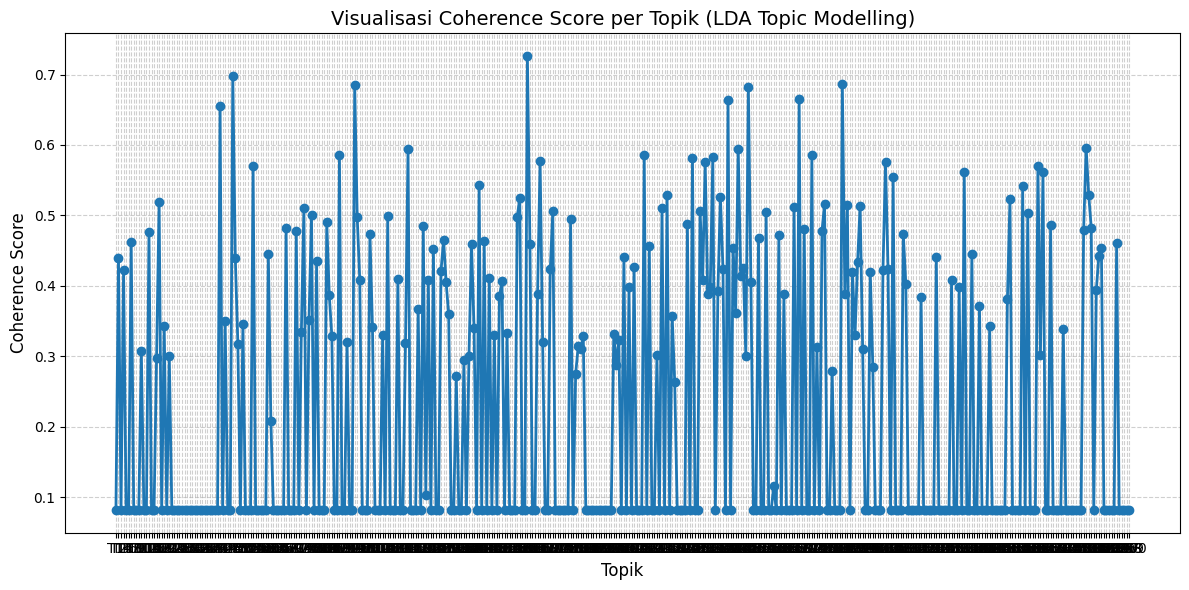

In [65]:
# ============================================
# Tahap: Visualisasi Coherence Score per Topik
# ============================================

import matplotlib.pyplot as plt

# 1️⃣ Pastikan df_coherence sudah ada dari tahap sebelumnya
# Jika belum, df_coherence berisi dua kolom: Topik dan Coherence_Score

plt.figure(figsize=(12, 6))
plt.plot(df_coherence['Topik'], df_coherence['Coherence_Score'], marker='o', linestyle='-', linewidth=2)

# 2️⃣ Tambahkan judul dan label
plt.title('Visualisasi Coherence Score per Topik (LDA Topic Modelling)', fontsize=14)
plt.xlabel('Topik', fontsize=12)
plt.ylabel('Coherence Score', fontsize=12)

# 3️⃣ Tambahkan grid agar mudah dibaca
plt.grid(True, linestyle='--', alpha=0.6)

# 4️⃣ Tampilkan plot
plt.tight_layout()
plt.show()

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
# Ambil fitur topik (T1, T2, ..., T100)
X = df_hasil_topik[[f'T{i+1}' for i in range(100)]]

# Ambil label kategori berita
y = df_hasil_topik['kategori']

# Cek struktur data
display(X)
display(y)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T91,T92,T93,T94,T95,T96,T97,T98,T99,T100
0,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,...,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017
1,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008
2,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
3,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
4,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
396,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004
397,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013
398,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,...,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007


,kategori
0,nasional
1,nasional
2,nasional
3,nasional
4,nasional
...,...
395,internasional
396,internasional
397,internasional
398,internasional


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [69]:
# Inisialisasi model SVM
svm_model = SVC(kernel='linear', random_state=42)

# Latih model
svm_model.fit(X_train, y_train)

# Prediksi
y_pred_svm = svm_model.predict(X_test)

In [70]:
# Inisialisasi model Softmax Regression
softmax_model = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)

# Latih model
softmax_model.fit(X_train, y_train)

# Prediksi
y_pred_softmax = softmax_model.predict(X_test)


=== Evaluasi Model: SVM ===
Accuracy : 0.4375
Precision: 0.3043052837573385
Recall   : 0.4375

Classification Report:
                precision    recall  f1-score   support

internasional       0.14      0.03      0.04        40
     nasional       0.47      0.85      0.60        40

     accuracy                           0.44        80
    macro avg       0.30      0.44      0.32        80
 weighted avg       0.30      0.44      0.32        80



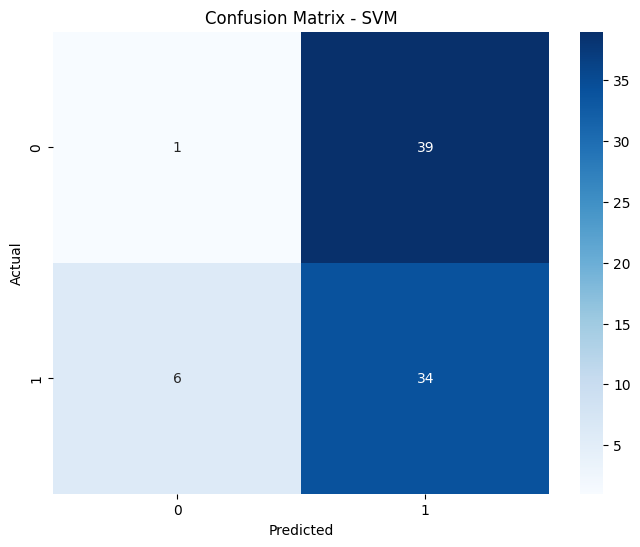


=== Evaluasi Model: Softmax Regression ===
Accuracy : 0.425
Precision: 0.3529411764705882
Recall   : 0.425

Classification Report:
                precision    recall  f1-score   support

internasional       0.25      0.07      0.12        40
     nasional       0.46      0.78      0.57        40

     accuracy                           0.42        80
    macro avg       0.35      0.42      0.34        80
 weighted avg       0.35      0.42      0.34        80



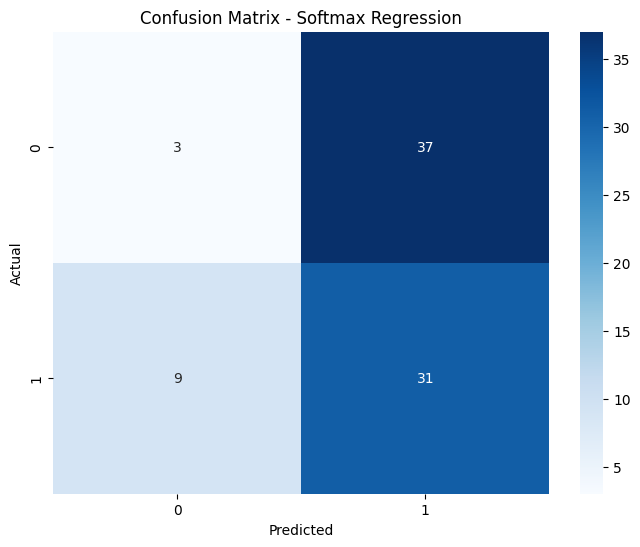

In [71]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluasi SVM
evaluasi_model(y_test, y_pred_svm, "SVM")

# Evaluasi Softmax
evaluasi_model(y_test, y_pred_softmax, "Softmax Regression")